# Self-Grounding Quality Check

Compare self-grounding results across GPT-5.3, MedGemma, and DermatoLlama.

- Parse success rates
- Box size distributions
- Visual examples
- Cross-model comparison on same cases

In [1]:
import os, sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

PROJECT_ROOT = "/scratch/jq2uw/derm_vlms"
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
IMAGES_DIR = os.path.join(RESULTS_DIR, "images")

MODELS = {
    "gpt53": "GPT-5.3",
    "medgemma": "MedGemma",
    "dermato_llama": "DermatoLlama",
}

# Load all self-grounding CSVs
dfs = {}
for key, label in MODELS.items():
    path = os.path.join(RESULTS_DIR, f"{key}_predictions_reason_viz_self.csv")
    if os.path.isfile(path):
        dfs[key] = pd.read_csv(path)
        print(f"{label}: {len(dfs[key])} rows loaded")
    else:
        print(f"{label}: NOT FOUND at {path}")

print(f"\nImages dir: {IMAGES_DIR}")

GPT-5.3: 3263 rows loaded
MedGemma: 3263 rows loaded
DermatoLlama: 3263 rows loaded

Images dir: /scratch/jq2uw/derm_vlms/results/images


## 1. Parse Success Rates

What fraction of reasoning sentences got valid bounding boxes?

In [2]:
def compute_box_stats(df, viz_col="viz_grounding"):
    """Compute parse success stats for a viz_grounding column."""
    total_targets = 0
    targets_with_box = 0
    rows_with_data = 0
    rows_all_ok = 0

    for _, row in df.iterrows():
        raw = row.get(viz_col)
        if pd.isna(raw) or raw == "":
            continue
        try:
            entries = json.loads(raw)
        except (json.JSONDecodeError, TypeError):
            continue
        if not entries:
            continue

        rows_with_data += 1
        n = len(entries)
        n_ok = sum(1 for e in entries if e.get("box") is not None)
        total_targets += n
        targets_with_box += n_ok
        if n_ok == n:
            rows_all_ok += 1

    return {
        "rows_with_data": rows_with_data,
        "rows_all_ok": rows_all_ok,
        "total_targets": total_targets,
        "targets_with_box": targets_with_box,
        "target_success_rate": targets_with_box / total_targets if total_targets else 0,
        "row_perfect_rate": rows_all_ok / rows_with_data if rows_with_data else 0,
    }

# Compute stats for each model and image mode
print(f"{'Model':<15} {'Column':<30} {'Targets':>8} {'With Box':>9} {'Success%':>9} {'Rows OK%':>9}")
print("-" * 85)
for key, label in MODELS.items():
    if key not in dfs:
        continue
    df = dfs[key]
    for col in ["viz_grounding", "viz_grounding_dscope", "viz_grounding_clinical"]:
        if col not in df.columns:
            continue
        stats = compute_box_stats(df, col)
        if stats["total_targets"] == 0:
            continue
        print(f"{label:<15} {col:<30} {stats['total_targets']:>8} {stats['targets_with_box']:>9} "
              f"{stats['target_success_rate']*100:>8.1f}% {stats['row_perfect_rate']*100:>8.1f}%")

Model           Column                          Targets  With Box  Success%  Rows OK%
-------------------------------------------------------------------------------------
GPT-5.3         viz_grounding                     31996     30694     95.9%     74.2%
GPT-5.3         viz_grounding_dscope              10583     10479     99.0%     93.1%
GPT-5.3         viz_grounding_clinical            10583      9953     94.0%     66.8%
MedGemma        viz_grounding                     43527     33787     77.6%     31.0%
MedGemma        viz_grounding_dscope              13699     12370     90.3%     51.6%
MedGemma        viz_grounding_clinical            13699     10140     74.0%     29.0%
DermatoLlama    viz_grounding                     31348     31348    100.0%    100.0%
DermatoLlama    viz_grounding_dscope               9993      9993    100.0%    100.0%
DermatoLlama    viz_grounding_clinical             9993      9993    100.0%    100.0%


## 2. Box Size Distributions

Are boxes reasonable sizes or mostly full-image / near-zero?

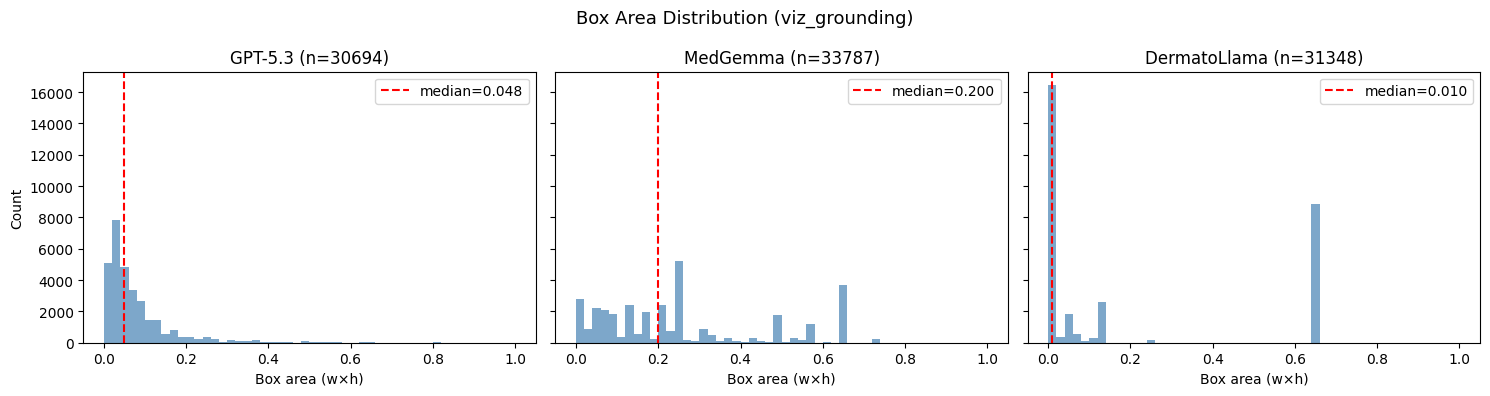

In [3]:
def extract_box_areas(df, viz_col="viz_grounding"):
    """Extract all box areas (w*h) from a viz column."""
    areas = []
    for _, row in df.iterrows():
        raw = row.get(viz_col)
        if pd.isna(raw) or raw == "":
            continue
        try:
            entries = json.loads(raw)
        except (json.JSONDecodeError, TypeError):
            continue
        for e in entries:
            box = e.get("box")
            if box and isinstance(box, dict):
                areas.append(box["w"] * box["h"])
    return np.array(areas)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (key, label) in zip(axes, MODELS.items()):
    if key not in dfs:
        ax.set_title(f"{label} — N/A")
        continue
    areas = extract_box_areas(dfs[key])
    ax.hist(areas, bins=50, range=(0, 1), alpha=0.7, color="steelblue")
    ax.axvline(np.median(areas), color="red", linestyle="--", label=f"median={np.median(areas):.3f}")
    ax.set_title(f"{label} (n={len(areas)})")
    ax.set_xlabel("Box area (w×h)")
    ax.legend()
axes[0].set_ylabel("Count")
plt.suptitle("Box Area Distribution (viz_grounding)", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Visual Examples — Grounding + Remapping Check

For combined-mode cases, shows 3 rows per case:
- **Row 1**: Clinical boxes on the photo image (original coordinates)
- **Row 2**: Dscope boxes on the dscope image (original coordinates)
- **Row 3**: Clinical boxes remapped onto the combined image

This lets you verify that remapping places boxes in the correct left/right region.

In [4]:
COLORS = ["#FF4444", "#44BB44", "#4444FF", "#FFAA00", "#AA44FF",
          "#FF44AA", "#44FFAA", "#AAFF44", "#4488FF", "#FF8844"]

def draw_boxes(ax, image, viz_json, title=""):
    """Draw bounding boxes on an image."""
    ax.imshow(image)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

    if pd.isna(viz_json) or viz_json == "":
        return
    try:
        entries = json.loads(viz_json)
    except (json.JSONDecodeError, TypeError):
        return

    w_img, h_img = image.size
    for i, entry in enumerate(entries):
        box = entry.get("box")
        if not box or not isinstance(box, dict):
            continue
        x = box["x"] * w_img
        y = box["y"] * h_img
        w = box["w"] * w_img
        h = box["h"] * h_img
        color = COLORS[i % len(COLORS)]
        rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                  edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        label = entry.get("text", "")[:30]
        ax.text(x, y - 2, label, fontsize=5, color=color,
                bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7))

1031 common combined cases across all models


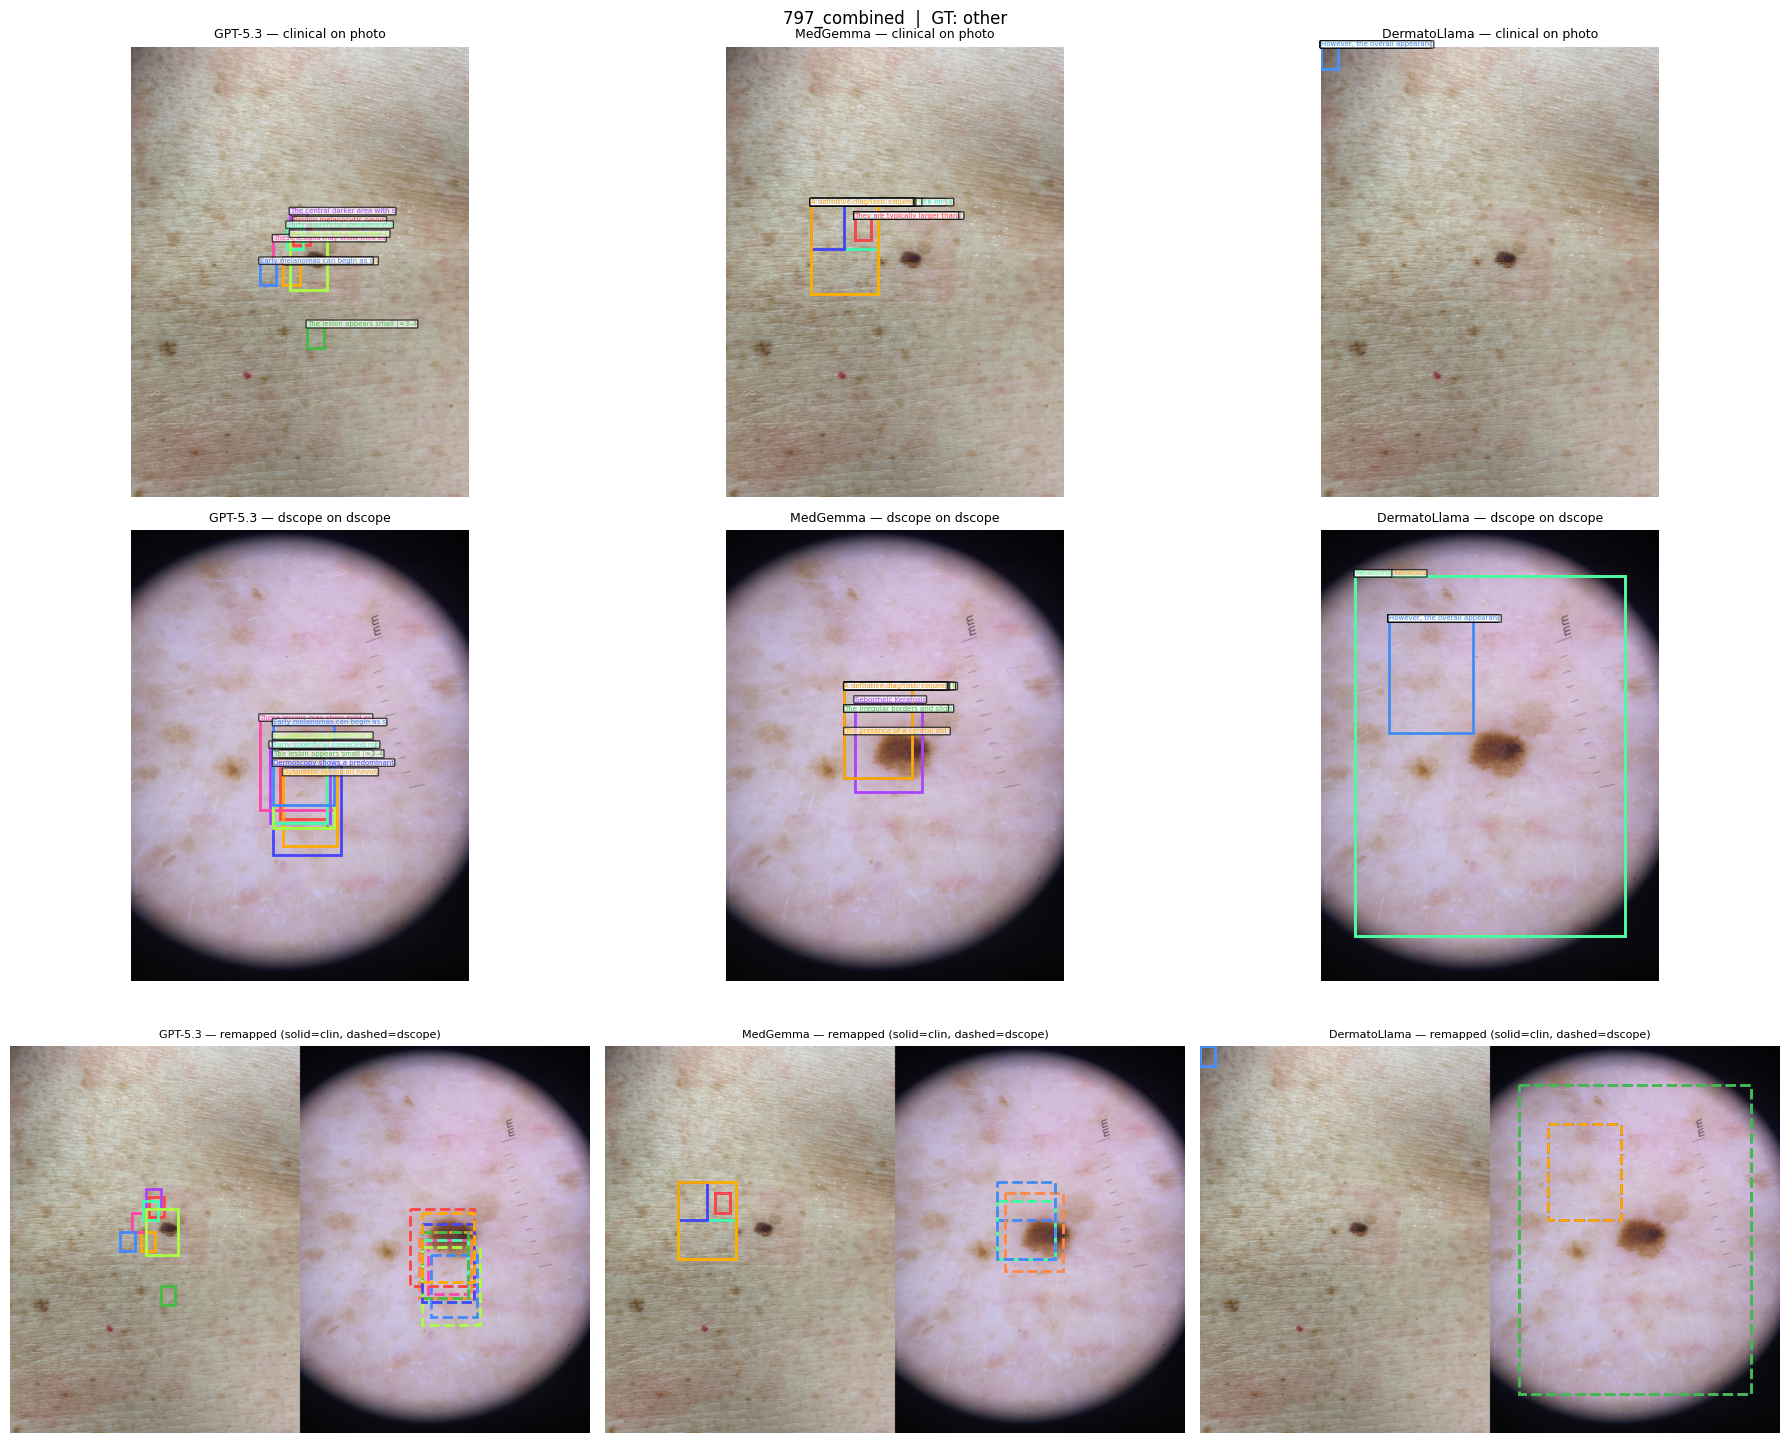

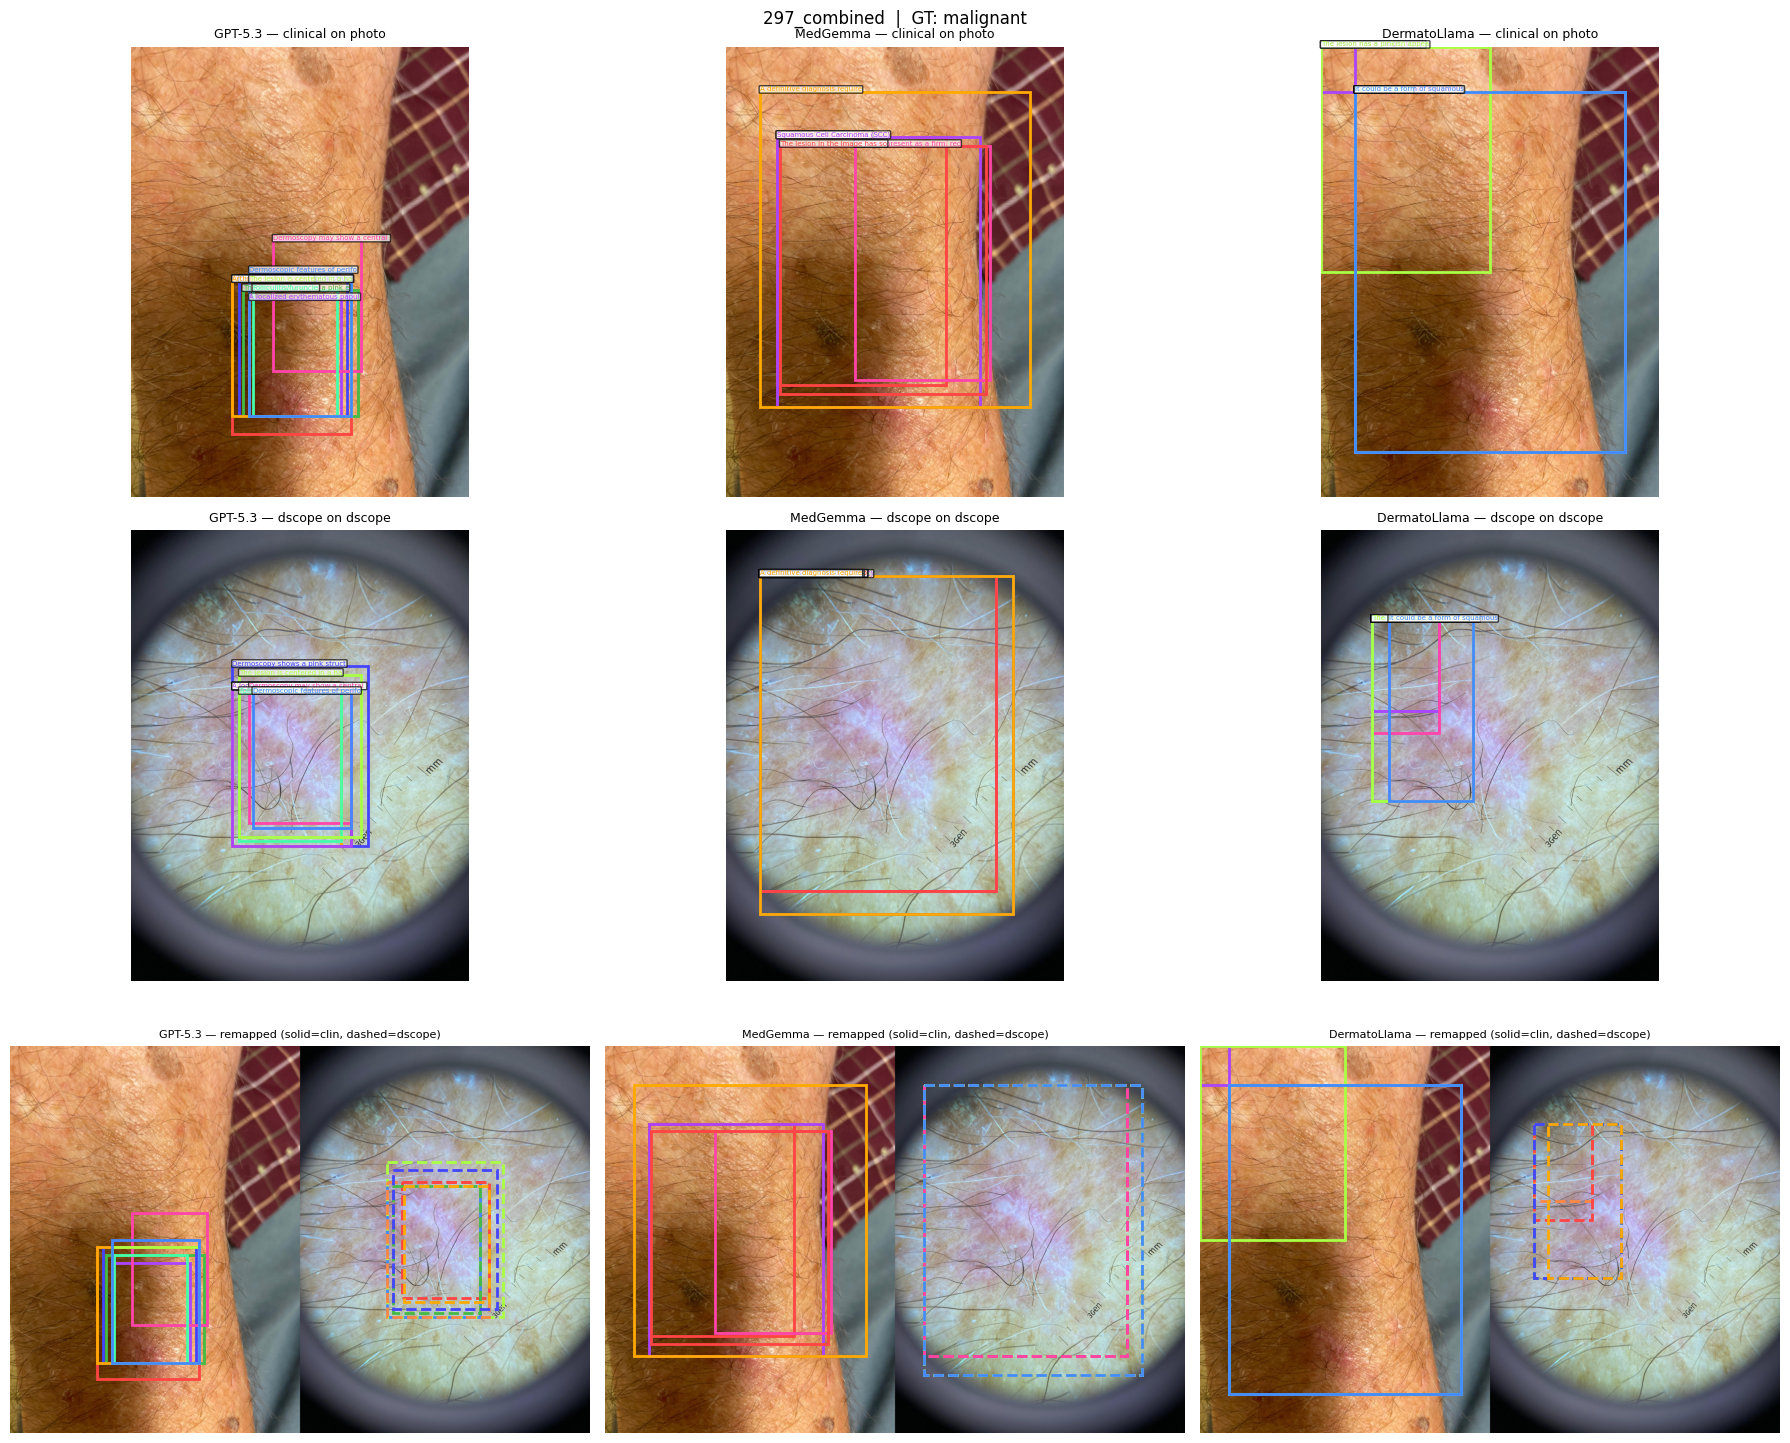

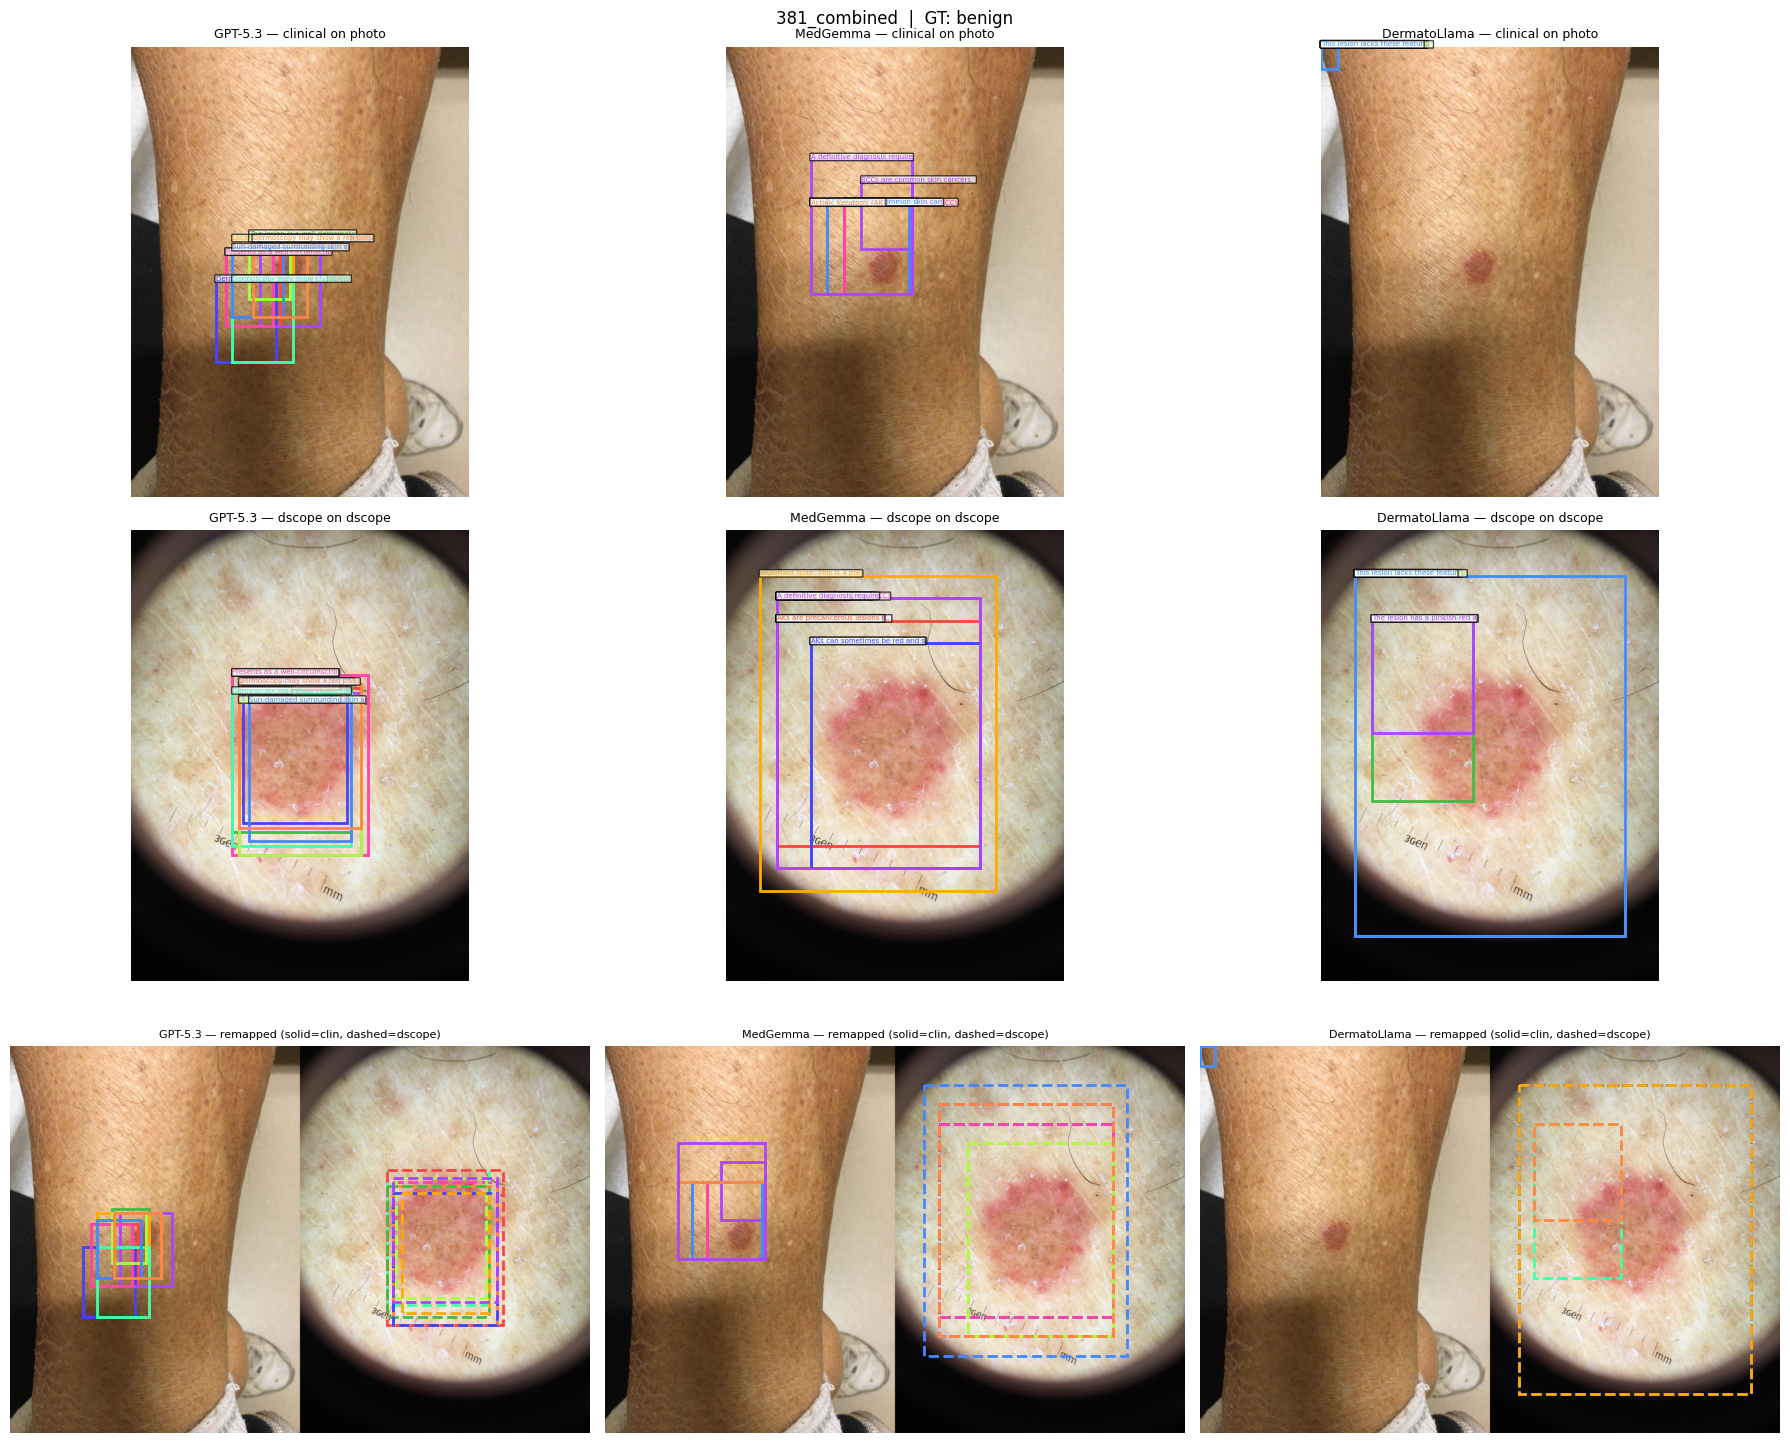

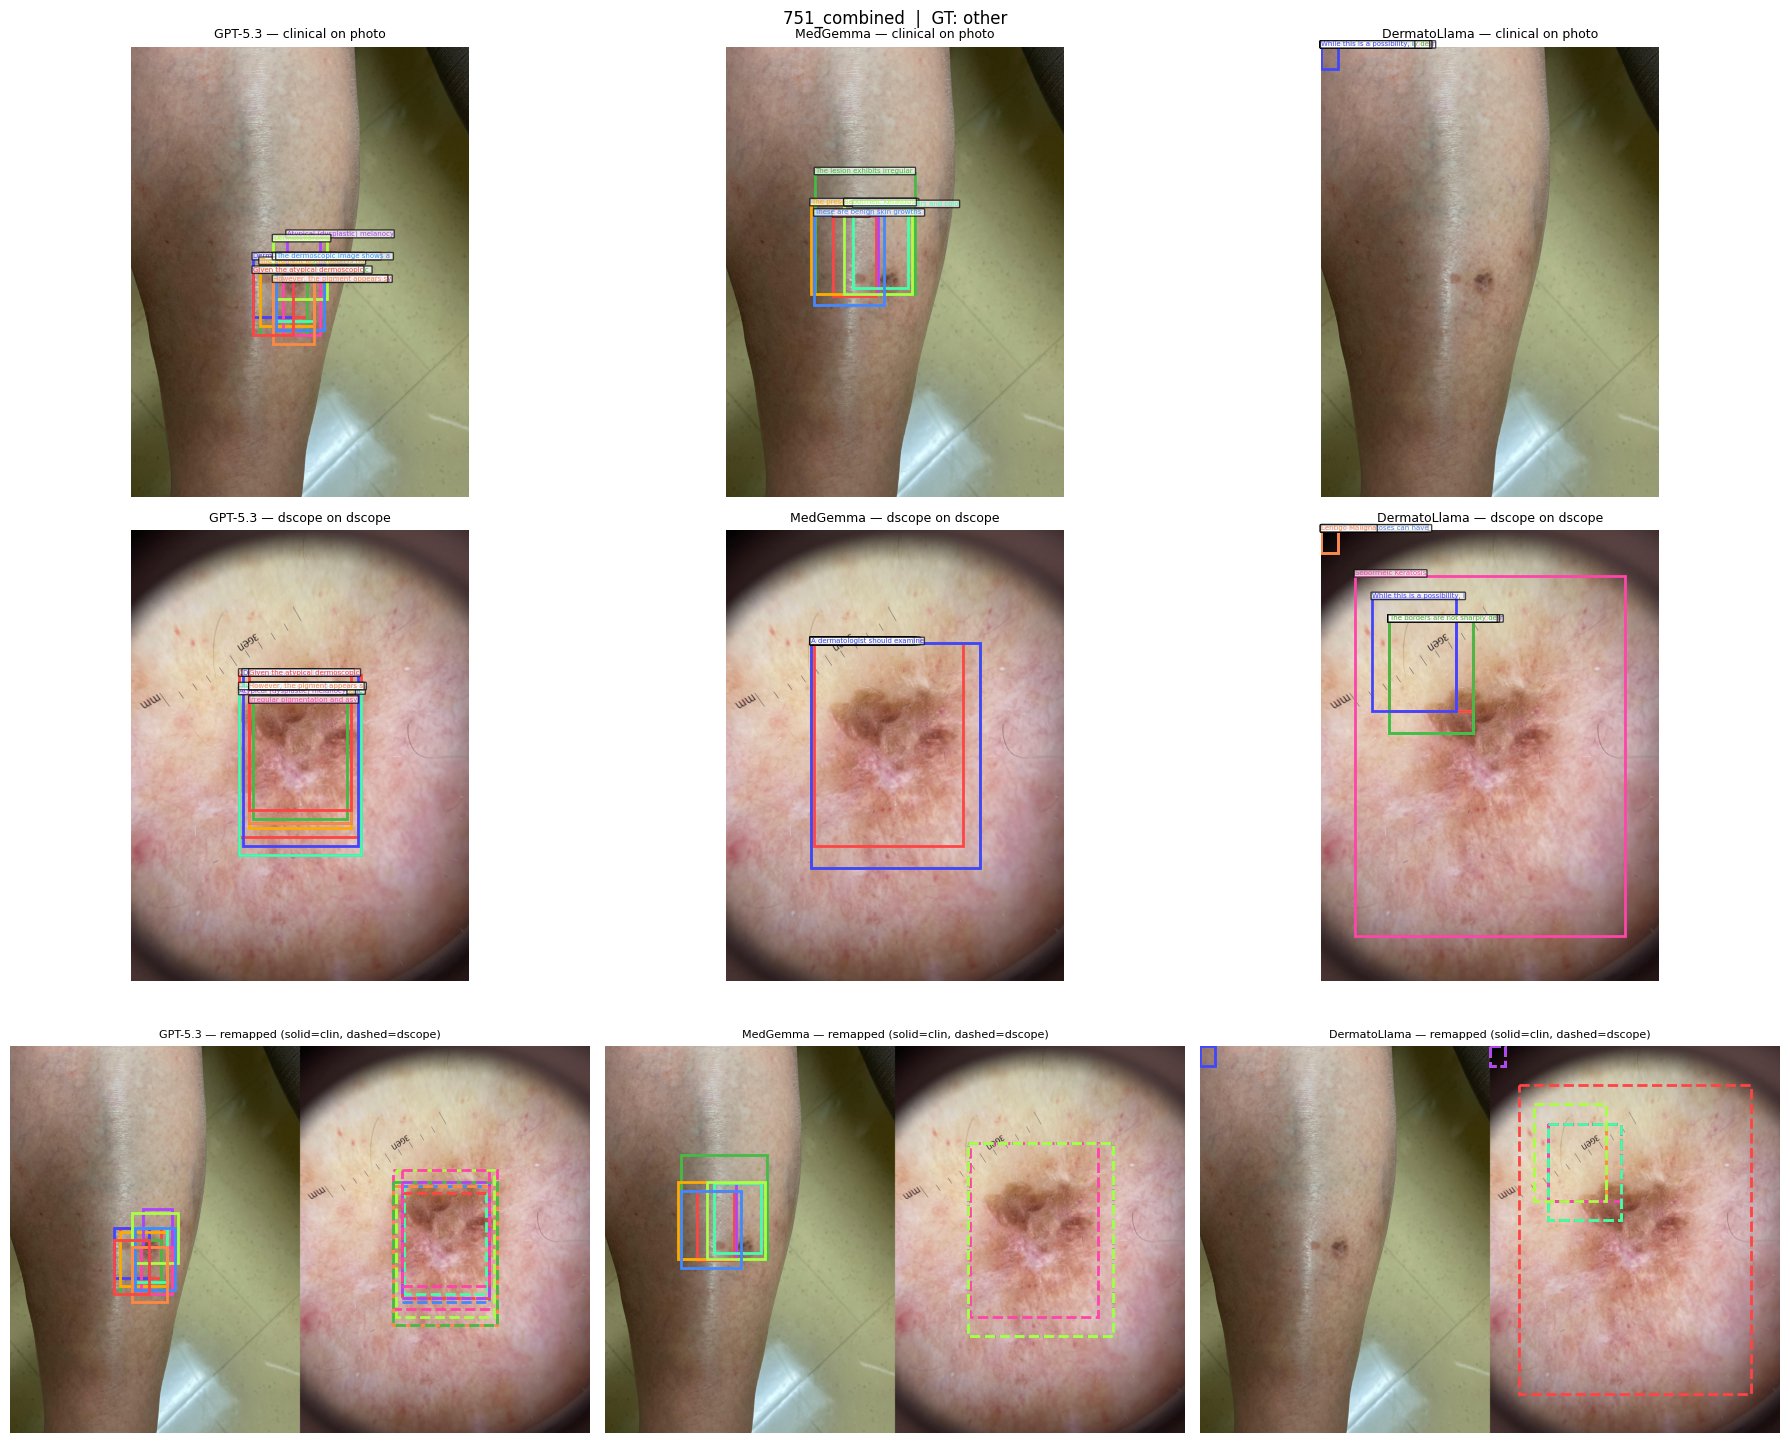

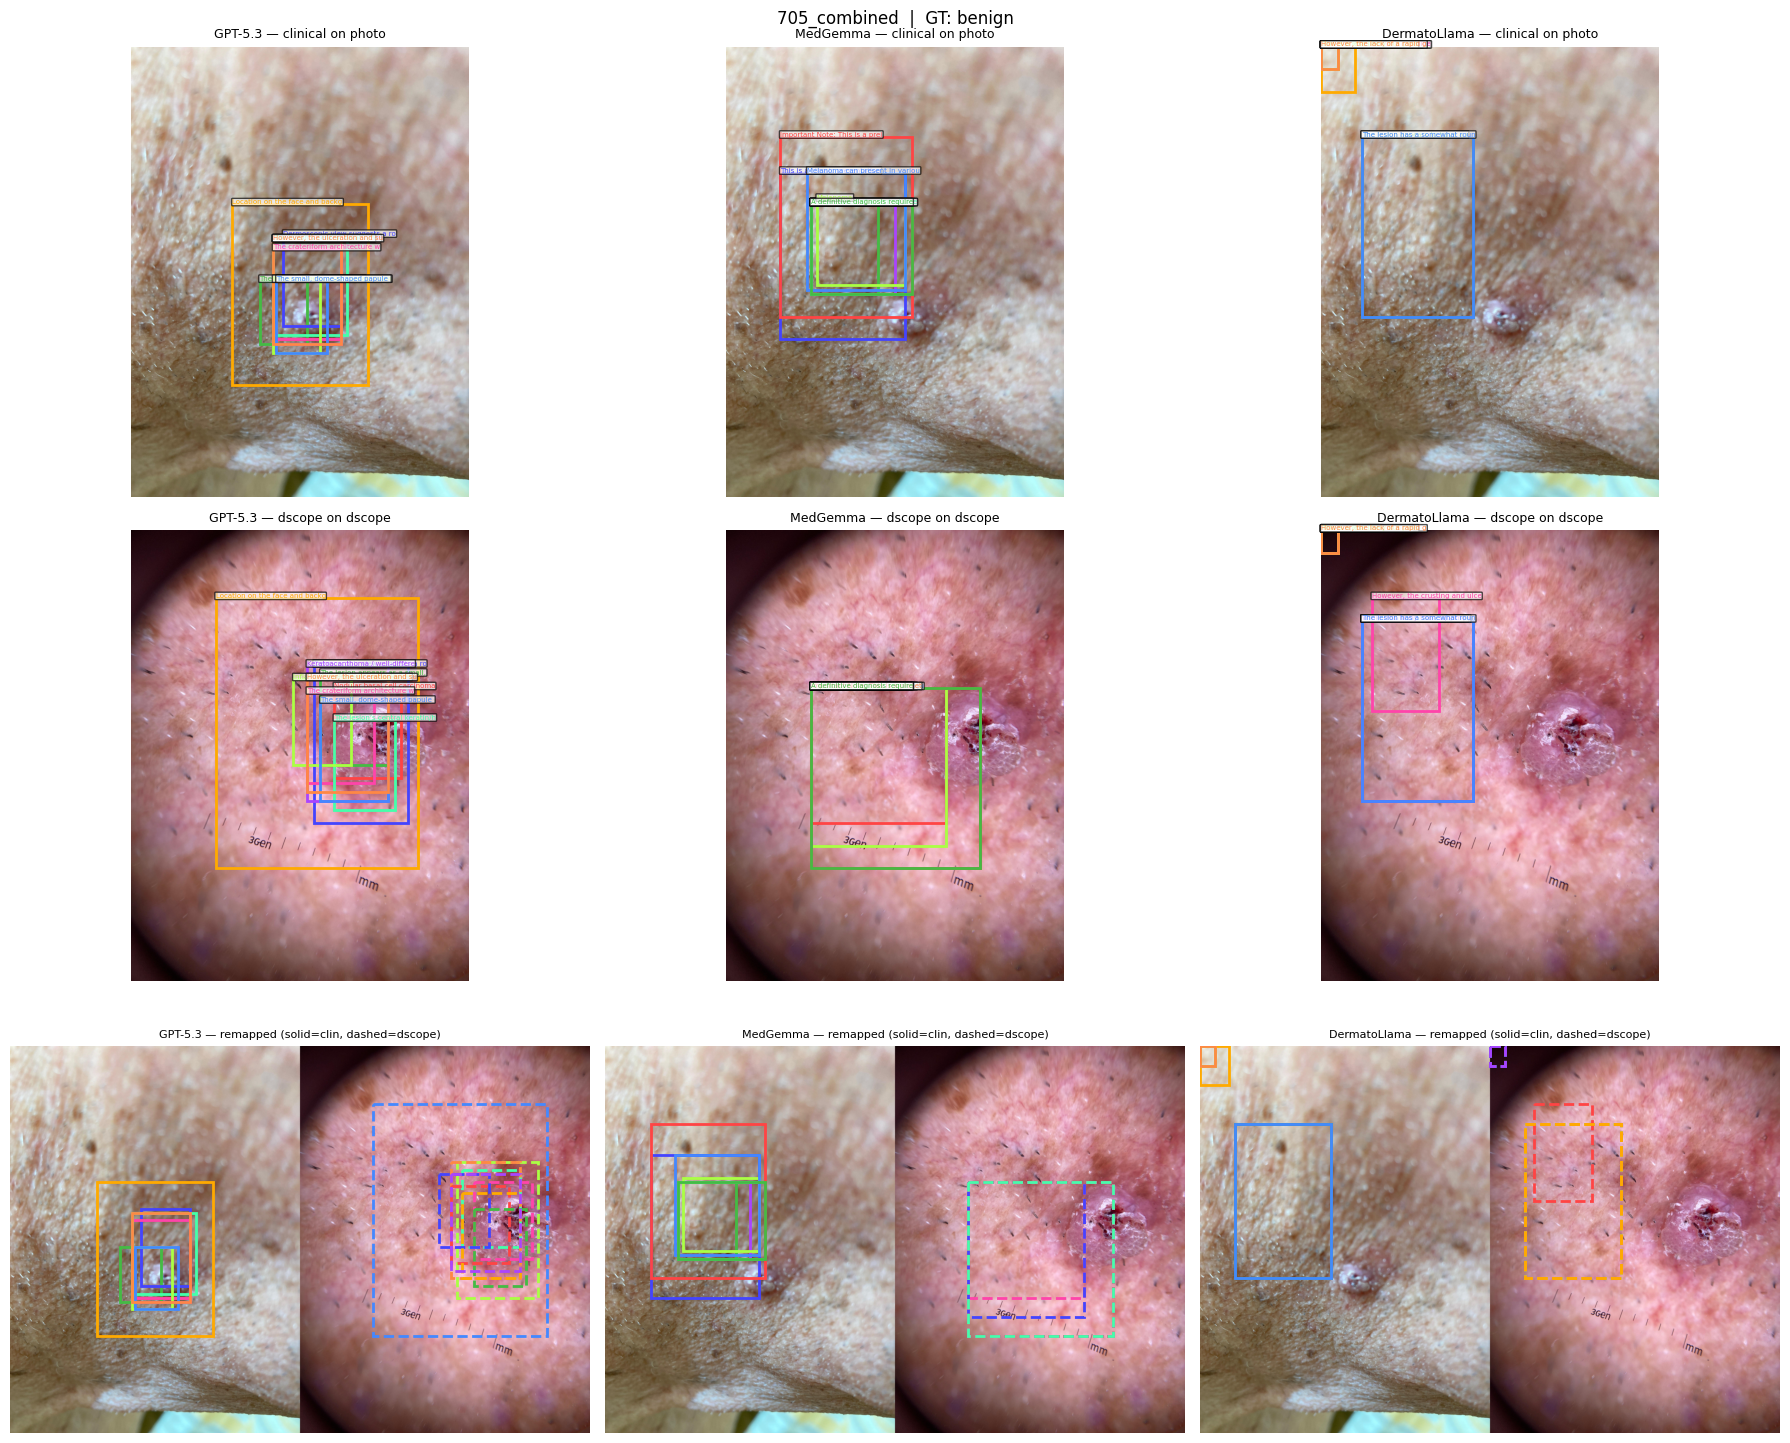

In [5]:
# Find common combined-mode cases across all 3 models
combined_ids = None
for key in MODELS:
    if key not in dfs:
        continue
    subset = dfs[key][dfs[key]["image_mode"] == "combined"]
    ids = set(subset["id"].tolist())
    combined_ids = ids if combined_ids is None else combined_ids & ids

print(f"{len(combined_ids)} common combined cases across all models")

np.random.seed(42)
sample_ids = np.random.choice(list(combined_ids), size=min(5, len(combined_ids)), replace=False)

def draw_boxes_on_ax(ax, img, viz_json, color_offset=0, linestyle="-"):
    """Draw boxes from viz JSON onto an existing ax (overlay-friendly)."""
    if pd.isna(viz_json) or viz_json == "":
        return
    try:
        entries = json.loads(viz_json)
    except (json.JSONDecodeError, TypeError):
        return
    w_img, h_img = img.size
    for i, entry in enumerate(entries):
        box = entry.get("box")
        if not box or not isinstance(box, dict):
            continue
        x = box["x"] * w_img
        y = box["y"] * h_img
        w = box["w"] * w_img
        h = box["h"] * h_img
        color = COLORS[(i + color_offset) % len(COLORS)]
        rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                  edgecolor=color, facecolor="none", linestyle=linestyle)
        ax.add_patch(rect)

for case_id in sample_ids:
    num = case_id.replace("_combined", "")
    photo_path = os.path.join(IMAGES_DIR, f"{num}_photo.jpg")
    dscope_path = os.path.join(IMAGES_DIR, f"{num}_dscope.jpg")
    combined_path = os.path.join(IMAGES_DIR, f"{num}_combined.jpg")

    # Layout: 3 columns (one per model), 3 rows:
    #   Row 0: clinical boxes on photo
    #   Row 1: dscope boxes on dscope
    #   Row 2: both clinical (solid) + dscope (dashed) remapped on combined
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))

    for col_idx, (key, label) in enumerate(MODELS.items()):
        if key not in dfs:
            for r in range(3):
                axes[r, col_idx].axis("off")
            continue
        row = dfs[key][dfs[key]["id"] == case_id].iloc[0]

        # Row 0: Clinical boxes on photo
        if os.path.isfile(photo_path):
            img = Image.open(photo_path).convert("RGB")
            draw_boxes(axes[0, col_idx], img,
                       row.get("viz_grounding_clinical", ""),
                       title=f"{label} — clinical on photo")
        else:
            axes[0, col_idx].set_title(f"{label} — photo not found")
            axes[0, col_idx].axis("off")

        # Row 1: Dscope boxes on dscope
        if os.path.isfile(dscope_path):
            img = Image.open(dscope_path).convert("RGB")
            draw_boxes(axes[1, col_idx], img,
                       row.get("viz_grounding_dscope", ""),
                       title=f"{label} — dscope on dscope")
        else:
            axes[1, col_idx].set_title(f"{label} — dscope not found")
            axes[1, col_idx].axis("off")

        # Row 2: Both remapped on combined (clinical=solid, dscope=dashed)
        if os.path.isfile(combined_path):
            img = Image.open(combined_path).convert("RGB")
            ax = axes[2, col_idx]
            ax.imshow(img)
            ax.set_title(f"{label} — remapped (solid=clin, dashed=dscope)", fontsize=8)
            ax.axis("off")
            draw_boxes_on_ax(ax, img, row.get("viz_grounding_clinical_remapped", ""),
                             color_offset=0, linestyle="-")
            draw_boxes_on_ax(ax, img, row.get("viz_grounding_dscope_remapped", ""),
                             color_offset=5, linestyle="--")
        else:
            axes[2, col_idx].set_title(f"{label} — combined not found")
            axes[2, col_idx].axis("off")

    gt = dfs[list(MODELS.keys())[0]][dfs[list(MODELS.keys())[0]]["id"] == case_id].iloc[0].get("ground_truth", "")
    plt.suptitle(f"{case_id}  |  GT: {gt}", fontsize=12)
    plt.tight_layout()
    plt.show()

## 5. Failure Analysis

Which models fail most often? Are there specific cases that all models fail on?

In [7]:
def get_failure_ids(df, viz_col="viz_grounding"):
    """Return IDs where at least one target has no box."""
    failures = []
    for _, row in df.iterrows():
        raw = row.get(viz_col)
        if pd.isna(raw) or raw == "":
            continue
        try:
            entries = json.loads(raw)
        except (json.JSONDecodeError, TypeError):
            continue
        if any(e.get("box") is None for e in entries):
            failures.append(row["id"])
    return set(failures)

failure_sets = {}
for key, label in MODELS.items():
    if key not in dfs:
        continue
    fails = get_failure_ids(dfs[key])
    failure_sets[key] = fails
    print(f"{label}: {len(fails)} cases with at least one missing box")

# Cases where ALL models failed
if len(failure_sets) == 3:
    all_fail = failure_sets["gpt53"] & failure_sets["medgemma"] & failure_sets["dermato_llama"]
    print(f"\nCases where ALL 3 models have failures: {len(all_fail)}")
    if all_fail:
        print(f"  Examples: {list(all_fail)[:10]}")

GPT-5.3: 831 cases with at least one missing box
MedGemma: 2199 cases with at least one missing box
DermatoLlama: 0 cases with at least one missing box

Cases where ALL 3 models have failures: 0


## 6. Summary Table

In [8]:
summary_rows = []
for key, label in MODELS.items():
    if key not in dfs:
        continue
    df = dfs[key]
    stats = compute_box_stats(df, "viz_grounding")
    areas = extract_box_areas(df, "viz_grounding")
    summary_rows.append({
        "Model": label,
        "Total Rows": len(df),
        "Targets": stats["total_targets"],
        "Box Success %": f"{stats['target_success_rate']*100:.1f}%",
        "Row Perfect %": f"{stats['row_perfect_rate']*100:.1f}%",
        "Median Area": f"{np.median(areas):.4f}" if len(areas) > 0 else "N/A",
        "Mean Area": f"{np.mean(areas):.4f}" if len(areas) > 0 else "N/A",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Model,Total Rows,Targets,Box Success %,Row Perfect %,Median Area,Mean Area
0,GPT-5.3,3263,31996,95.9%,74.2%,0.0480,0.0773
1,MedGemma,3263,43527,77.6%,31.0%,0.2000,0.2494
2,DermatoLlama,3263,31348,100.0%,100.0%,0.0100,0.2004
